In [1]:
import sys
import os
import pandas as pd 
import numpy as np
import pytest

project_root = os.path.dirname(os.path.dirname(os.path.abspath('.')))
sys.path.append(project_root)

from practicas import examen

In [2]:
import os
print(os.getcwd())


/home/eduardo-castillo/Documentos/diplomado/repositorio/Diplomado_DataSciene/practicas/examen


In [3]:
user=pd.read_excel(r'users.xlsx')

In [4]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userID            138 non-null    object 
 1   latitude          138 non-null    float64
 2   longitude         138 non-null    float64
 3   smoker            138 non-null    object 
 4   drink_level       138 non-null    object 
 5   dress_preference  138 non-null    object 
 6   ambience          138 non-null    object 
 7   transport         138 non-null    object 
 8   marital_status    138 non-null    object 
 9   hijos             138 non-null    object 
 10  birth_year        138 non-null    int64  
 11  interest          138 non-null    object 
 12  personality       138 non-null    object 
 13  religion          138 non-null    object 
 14  activity          138 non-null    object 
 15  color             138 non-null    object 
 16  weight            138 non-null    int64  
 1

In [5]:
user.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,False,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,False,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87
2,U1003,22.119847,-100.946527,False,social drinker,formal,family,public,single,independent,1989,none,hard-worker,Catholic,student,blue,60,low,1.69
3,U1004,18.867000,-99.183000,False,abstemious,informal,family,public,single,independent,1940,variety,hard-worker,none,professional,green,44,medium,1.53
4,U1005,22.183477,-100.959891,False,abstemious,no preference,family,public,single,independent,1992,none,thrifty-protector,Catholic,student,black,65,medium,1.69


# Ingenieria de Variables 

In [6]:
rating=pd.read_csv(r'ratings.csv')
rating.head()

,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1
2,U1077,132825,2,2,2
3,U1077,135060,1,2,2
4,U1068,135104,1,1,2


In [7]:
## Agrupamos para por USER ID para dar 

rating=rating.groupby('userID').agg(
    lugares_visitados = ('placeID', 'count'),
    promedio_rating = ('rating', 'mean'),
    promedio_food_rating = ('food_rating', 'mean'),
    promedio_service_rating = ('service_rating', 'mean')
).reset_index()




In [8]:
rating.head()

,userID,lugares_visitados,promedio_rating,promedio_food_rating,promedio_service_rating
0,U1001,9,1.111111,1.222222,1.222222
1,U1002,10,1.400000,1.400000,1.000000
2,U1003,13,1.615385,1.692308,1.461538
3,U1004,8,1.875000,1.875000,1.750000
4,U1005,9,1.333333,1.444444,1.000000


In [9]:
## Unimos el df con la base USER
dataset=pd.merge(user,rating,how='left',on='userID')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   userID                   138 non-null    object 
 1   latitude                 138 non-null    float64
 2   longitude                138 non-null    float64
 3   smoker                   138 non-null    object 
 4   drink_level              138 non-null    object 
 5   dress_preference         138 non-null    object 
 6   ambience                 138 non-null    object 
 7   transport                138 non-null    object 
 8   marital_status           138 non-null    object 
 9   hijos                    138 non-null    object 
 10  birth_year               138 non-null    int64  
 11  interest                 138 non-null    object 
 12  personality              138 non-null    object 
 13  religion                 138 non-null    object 
 14  activity                 1

In [10]:
userpayment=pd.read_csv(r'userpayment.csv')

### Validamos que no haya Duplicados en la llave primaria 

userpayment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userID    177 non-null    object
 1   Upayment  177 non-null    object
dtypes: object(2)
memory usage: 2.9+ KB


In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
df = encoder.fit_transform(userpayment[['Upayment']])

df_dummies = pd.DataFrame(df, columns=encoder.get_feature_names_out(['Upayment']))
df_final = pd.concat([userpayment, df_dummies], axis=1)

df_final.drop(columns='Upayment',inplace=True)
df_final.drop_duplicates(subset='userID',inplace=True)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 0 to 176
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   userID                        133 non-null    object 
 1   Upayment_American_Express     133 non-null    float64
 2   Upayment_MasterCard-Eurocard  133 non-null    float64
 3   Upayment_VISA                 133 non-null    float64
 4   Upayment_bank_debit_cards     133 non-null    float64
 5   Upayment_cash                 133 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.3+ KB


In [12]:
dataset=dataset.merge(df_final,how='left',on='userID')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   userID                        138 non-null    object 
 1   latitude                      138 non-null    float64
 2   longitude                     138 non-null    float64
 3   smoker                        138 non-null    object 
 4   drink_level                   138 non-null    object 
 5   dress_preference              138 non-null    object 
 6   ambience                      138 non-null    object 
 7   transport                     138 non-null    object 
 8   marital_status                138 non-null    object 
 9   hijos                         138 non-null    object 
 10  birth_year                    138 non-null    int64  
 11  interest                      138 non-null    object 
 12  personality                   138 non-null    object 
 13  relig

### Seleccionamos la Variable Objetivo

In [13]:
dataset.head()

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,height,lugares_visitados,promedio_rating,promedio_food_rating,promedio_service_rating,Upayment_American_Express,Upayment_MasterCard-Eurocard,Upayment_VISA,Upayment_bank_debit_cards,Upayment_cash
0,U1001,22.139997,-100.978803,False,abstemious,informal,family,on foot,single,independent,...,1.77,9,1.111111,1.222222,1.222222,0.0,0.0,0.0,0.0,1.0
1,U1002,22.150087,-100.983325,False,abstemious,informal,family,public,single,independent,...,1.87,10,1.400000,1.400000,1.000000,0.0,0.0,0.0,0.0,1.0
2,U1003,22.119847,-100.946527,False,social drinker,formal,family,public,single,independent,...,1.69,13,1.615385,1.692308,1.461538,0.0,0.0,0.0,0.0,1.0
3,U1004,18.867000,-99.183000,False,abstemious,informal,family,public,single,independent,...,1.53,8,1.875000,1.875000,1.750000,0.0,0.0,0.0,0.0,1.0
4,U1005,22.183477,-100.959891,False,abstemious,no preference,family,public,single,independent,...,1.69,9,1.333333,1.444444,1.000000,0.0,0.0,0.0,0.0,1.0


In [14]:
### Seleccionamos la variable Smoker, sera nuestra variable objetivo
### La variable indica si es fumador o no, es de tipo binaria



dataset['smoker'].value_counts()


## Observamos que tiene una tercera categoria que es desconocida, por lo cual rellenamos con la moda


smoker
False    109
True      26
?          3
Name: count, dtype: int64

In [15]:
###Rellenamos con la moda

dataset['smoker'] = dataset['smoker'].replace('?',dataset['smoker'].mode()[0])
dataset['smoker']=dataset['smoker'].astype(int)
dataset['smoker'].value_counts()

/tmp/ipykernel_5608/1627402753.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['smoker'] = dataset['smoker'].replace('?',dataset['smoker'].mode()[0])


smoker
0    112
1     26
Name: count, dtype: int64

#### Limpieza y Transformacion de los Datos

In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   userID                        138 non-null    object 
 1   latitude                      138 non-null    float64
 2   longitude                     138 non-null    float64
 3   smoker                        138 non-null    int64  
 4   drink_level                   138 non-null    object 
 5   dress_preference              138 non-null    object 
 6   ambience                      138 non-null    object 
 7   transport                     138 non-null    object 
 8   marital_status                138 non-null    object 
 9   hijos                         138 non-null    object 
 10  birth_year                    138 non-null    int64  
 11  interest                      138 non-null    object 
 12  personality                   138 non-null    object 
 13  relig

### Identificamos las Variables Unarias 

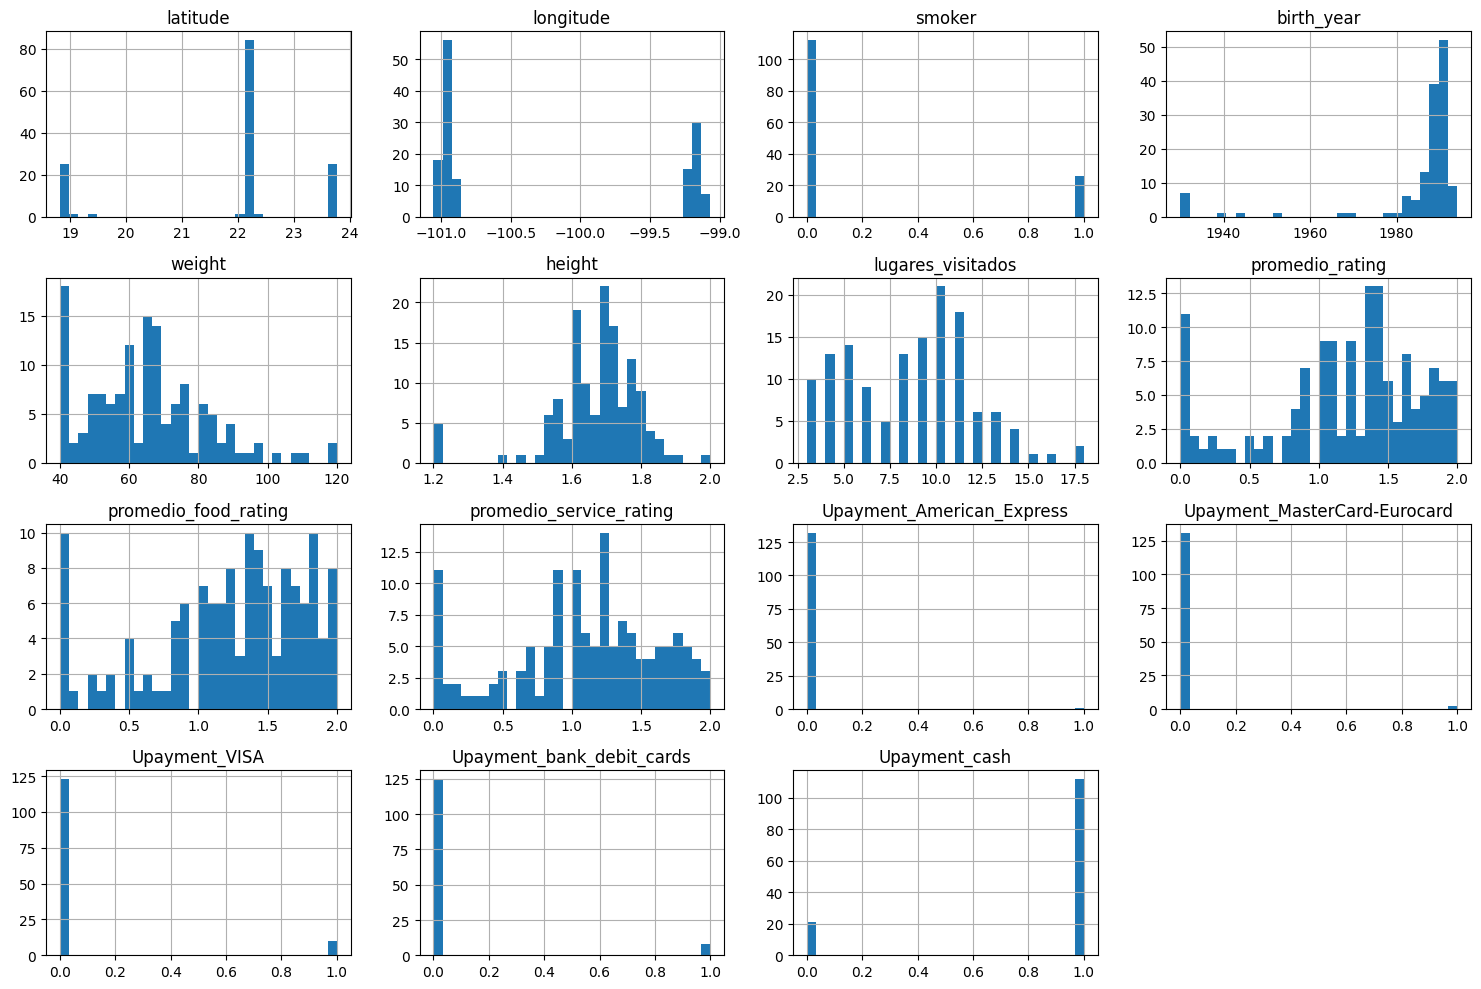

In [17]:
# Identificamos Columnas unarias

import matplotlib.pyplot as plt
# Calcular varianza
num_cols = dataset.select_dtypes(include=['int64', 'float64'])
varianzas = num_cols.var()


num_cols = dataset.select_dtypes(include=['int64', 'float64'])

# Graficar histogramas para todas las columnas
num_cols.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()


In [18]:
### Identificamos las variables unarias

unarias = [col for col in dataset.columns if dataset[col].nunique() == 1]
print("Variables unarias:", unarias)


Variables unarias: []


Según la revisión del dataset, todas las variables presentan más de un valor único, lo que indica que no existen columnas unarias.

### Detección y remoción de variables poco pobladas. 65% 

In [19]:
from practicas import P3
resumen = P3.check_data_completeness_nombrecompleto(dataset)

In [20]:
dataset

,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,...,height,lugares_visitados,promedio_rating,promedio_food_rating,promedio_service_rating,Upayment_American_Express,Upayment_MasterCard-Eurocard,Upayment_VISA,Upayment_bank_debit_cards,Upayment_cash
0,U1001,22.139997,-100.978803,0,abstemious,informal,family,on foot,single,independent,...,1.77,9,1.111111,1.222222,1.222222,0.0,0.0,0.0,0.0,1.0
1,U1002,22.150087,-100.983325,0,abstemious,informal,family,public,single,independent,...,1.87,10,1.400000,1.400000,1.000000,0.0,0.0,0.0,0.0,1.0
2,U1003,22.119847,-100.946527,0,social drinker,formal,family,public,single,independent,...,1.69,13,1.615385,1.692308,1.461538,0.0,0.0,0.0,0.0,1.0
3,U1004,18.867000,-99.183000,0,abstemious,informal,family,public,single,independent,...,1.53,8,1.875000,1.875000,1.750000,0.0,0.0,0.0,0.0,1.0
4,U1005,22.183477,-100.959891,0,abstemious,no preference,family,public,single,independent,...,1.69,9,1.333333,1.444444,1.000000,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,U1134,22.149654,-100.998610,0,casual drinker,no preference,family,public,single,independent,...,1.65,16,1.437500,1.187500,1.187500,0.0,0.0,0.0,0.0,1.0
134,U1135,22.170396,-100.949936,0,casual drinker,informal,family,on foot,single,kids,...,1.54,14,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1.0
135,U1136,22.149607,-100.997235,1,social drinker,no preference,friends,car owner,single,independent,...,1.60,10,1.600000,1.700000,1.800000,0.0,0.0,0.0,0.0,1.0
136,U1137,22.144803,-100.944623,0,social drinker,formal,family,public,single,independent,...,1.78,14,1.857143,1.785714,1.928571,0.0,0.0,0.0,0.0,1.0


El análisis del DataFrame resumen muestra que todas las variables cuentan con al menos un 65 % de valores no nulos, lo que asegura una base de datos suficientemente completa para continuar el análisis.

In [21]:
resumen.head()

,num_nulos,completitud_%,dtype,min,max,mean,std,tipo_columna
userID,0,100.0,object,NaN,NaN,NaN,NaN,Discreta
latitude,0,100.0,float64,18.813348,23.771030,21.810389,1.552529,Continua
longitude,0,100.0,float64,-101.054680,-99.067106,-100.291857,0.869916,Continua
smoker,0,100.0,int64,0.000000,1.000000,0.188406,0.392460,Discreta
drink_level,0,100.0,object,NaN,NaN,NaN,NaN,Discreta


### Trabajamos con los valores nulos 

In [22]:
dataset.isnull().sum()

userID                          0
latitude                        0
longitude                       0
smoker                          0
drink_level                     0
dress_preference                0
ambience                        0
transport                       0
marital_status                  0
hijos                           0
birth_year                      0
interest                        0
personality                     0
religion                        0
activity                        0
color                           0
weight                          0
budget                          0
height                          0
lugares_visitados               0
promedio_rating                 0
promedio_food_rating            0
promedio_service_rating         0
Upayment_American_Express       5
Upayment_MasterCard-Eurocard    5
Upayment_VISA                   5
Upayment_bank_debit_cards       5
Upayment_cash                   5
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   userID                        138 non-null    object 
 1   latitude                      138 non-null    float64
 2   longitude                     138 non-null    float64
 3   smoker                        138 non-null    int64  
 4   drink_level                   138 non-null    object 
 5   dress_preference              138 non-null    object 
 6   ambience                      138 non-null    object 
 7   transport                     138 non-null    object 
 8   marital_status                138 non-null    object 
 9   hijos                         138 non-null    object 
 10  birth_year                    138 non-null    int64  
 11  interest                      138 non-null    object 
 12  personality                   138 non-null    object 
 13  relig

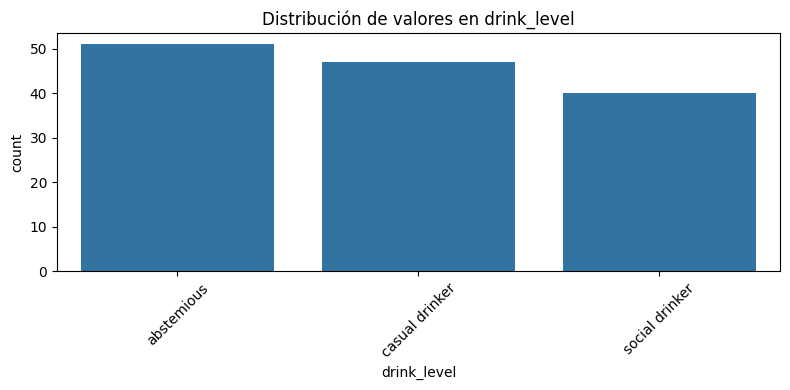

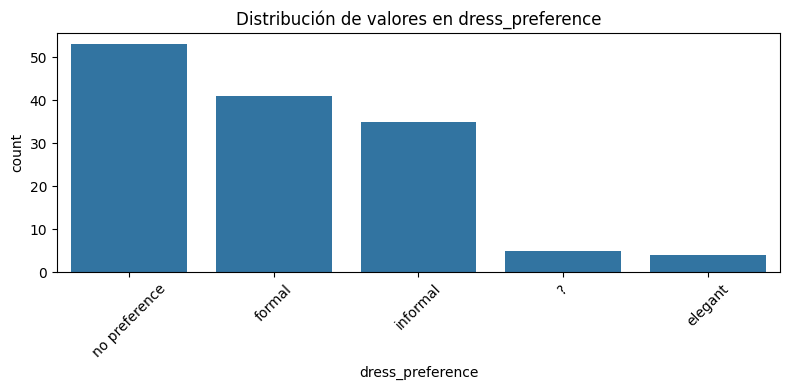

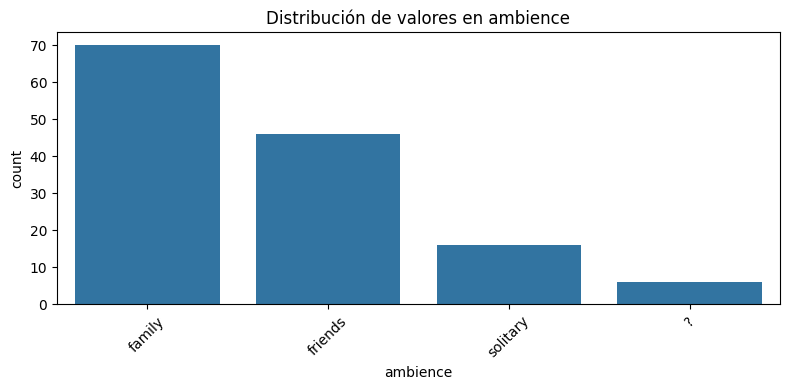

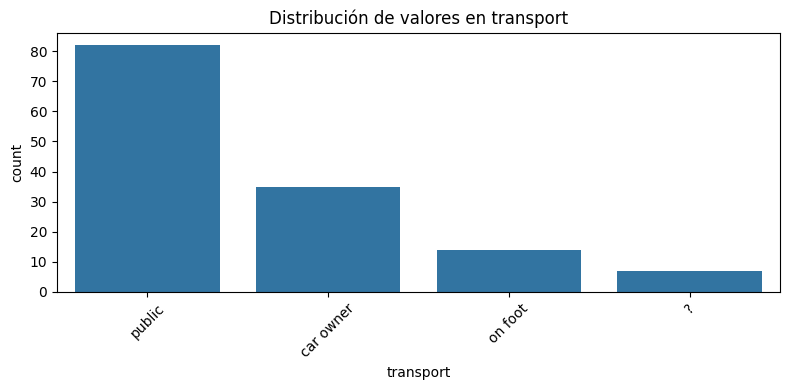

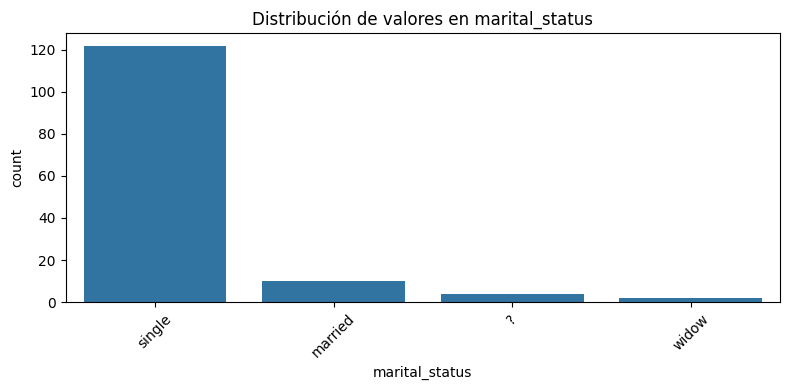

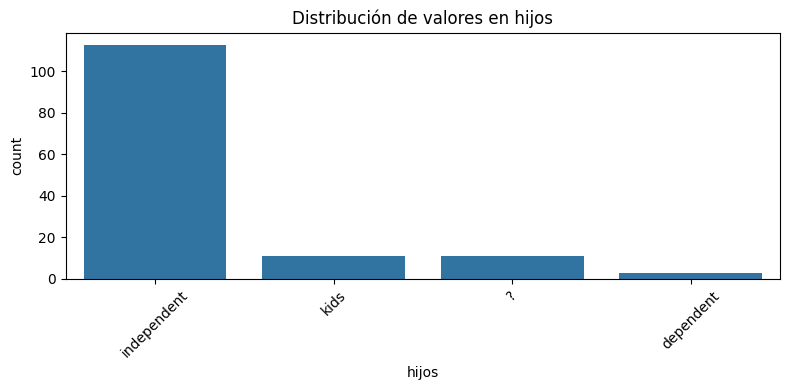

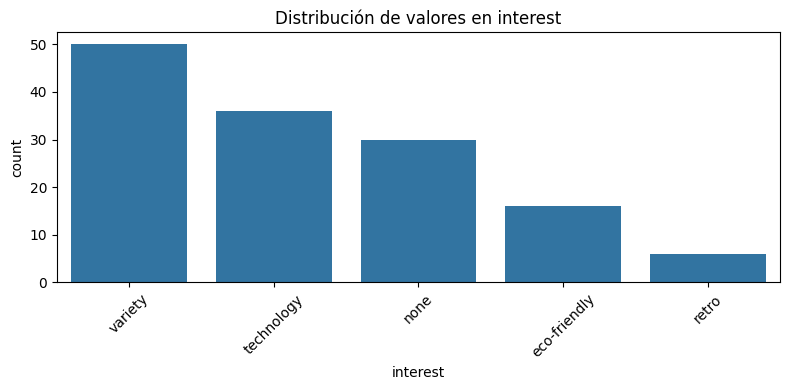

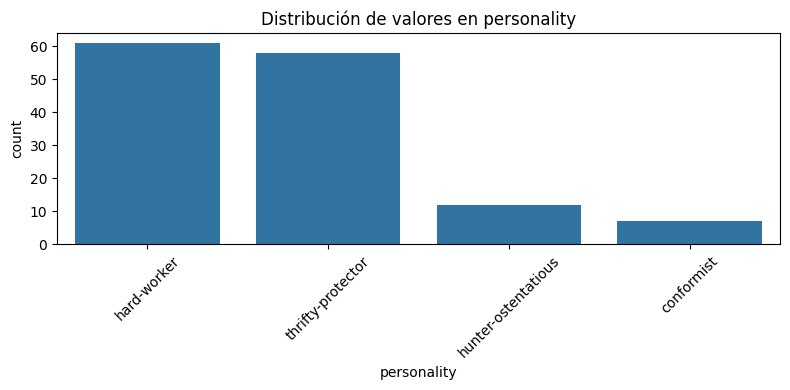

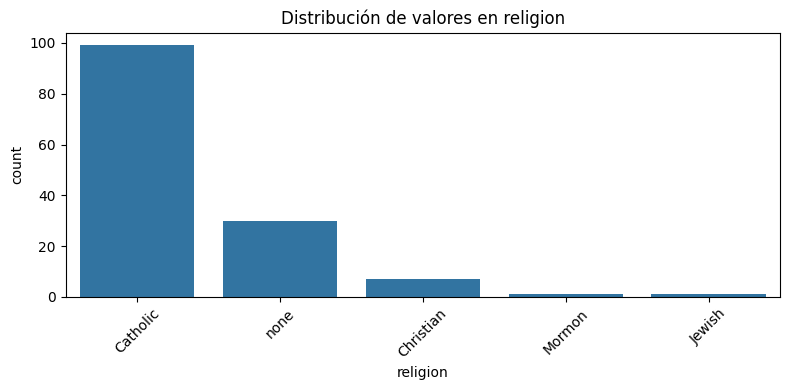

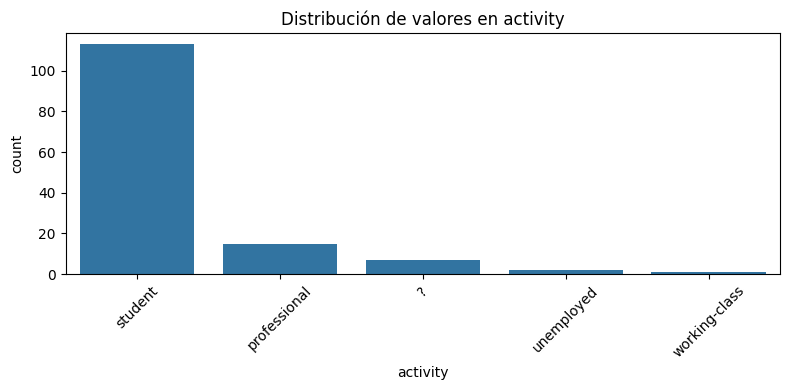

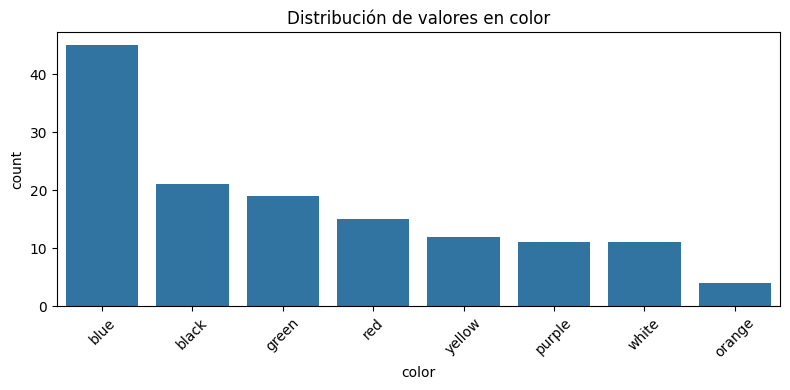

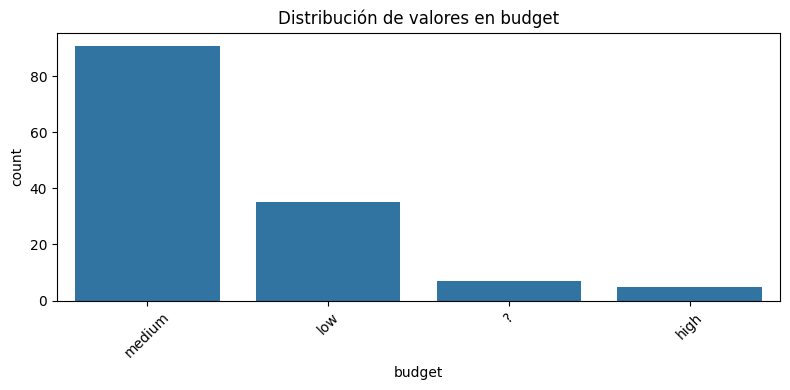

In [23]:
### Aparentemente el dataset no contiene valores numericos pero si valores de caracter especial, estas se encuentras en las columnas categoricas

dataset.info()

import matplotlib.pyplot as plt
import seaborn as sns


obj_cols = dataset.select_dtypes(include='object').columns.tolist()


if 'userID' in obj_cols:
    obj_cols.remove('userID')

for col in obj_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=dataset[col], order=dataset[col].value_counts().index)
    plt.title(f"Distribución de valores en {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [24]:
### Visualizamos los valores de caracter especial 
obj_cols 

['drink_level',
 'dress_preference',
 'ambience',
 'transport',
 'marital_status',
 'hijos',
 'interest',
 'personality',
 'religion',
 'activity',
 'color',
 'budget']

In [25]:
dataset['dress_preference']=dataset['dress_preference'].replace('?',dataset['dress_preference'].mode()[0])
dataset['ambience']=dataset['ambience'].replace('?',dataset['ambience'].mode()[0])
dataset['transport']=dataset['transport'].replace('?',dataset['transport'].mode()[0])


In [26]:
### Para la categoria hijos 

dataset['hijos'].value_counts(normalize=True)
dataset['marital_status']=dataset['marital_status'].replace('?','unknow')
dataset['hijos']=dataset['hijos'].replace('?','unknow')
dataset['activity']=dataset['activity'].replace('?','undefined')
dataset['budget']=dataset['budget'].replace('?','unspecified')

#### Estas variables numericas para sus valores faltantes las rellenamos con 0 porque los clientes no especificaron su metodo de pago.

#Upayment_MasterCard-Eurocard  
#Upayment_VISA                 
#Upayment_bank_debit_cards     
#Upayment_cash       


dataset['Upayment_MasterCard-Eurocard']=dataset['Upayment_MasterCard-Eurocard'].fillna(0)    
dataset['Upayment_American_Express']=dataset['Upayment_American_Express'].fillna(0)          
dataset['Upayment_VISA']=dataset['Upayment_VISA'].fillna(0)
dataset['Upayment_bank_debit_cards']=dataset['Upayment_bank_debit_cards'].fillna(0)
dataset['Upayment_cash']=dataset['Upayment_cash'].fillna(0)

## Calculamos los valores Outliers de la estatura y del peso 



In [27]:
dataset.columns

Index(['userID', 'latitude', 'longitude', 'smoker', 'drink_level',
       'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos',
       'birth_year', 'interest', 'personality', 'religion', 'activity',
       'color', 'weight', 'budget', 'height', 'lugares_visitados',
       'promedio_rating', 'promedio_food_rating', 'promedio_service_rating',
       'Upayment_American_Express', 'Upayment_MasterCard-Eurocard',
       'Upayment_VISA', 'Upayment_bank_debit_cards', 'Upayment_cash'],
      dtype='object')

In [28]:
inferior,superior=P3.utils.calcular_IQR(dataset,'height')
inf_weight,sup_weigth=P3.utils.calcular_IQR(dataset,'weight')
dataset= dataset[
    (dataset['height'] >= inferior) & (dataset['height'] <= superior) &
    (dataset['weight'] >= inf_weight) & (dataset['weight'] <= sup_weigth)
]

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 0 to 137
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   userID                        128 non-null    object 
 1   latitude                      128 non-null    float64
 2   longitude                     128 non-null    float64
 3   smoker                        128 non-null    int64  
 4   drink_level                   128 non-null    object 
 5   dress_preference              128 non-null    object 
 6   ambience                      128 non-null    object 
 7   transport                     128 non-null    object 
 8   marital_status                128 non-null    object 
 9   hijos                         128 non-null    object 
 10  birth_year                    128 non-null    int64  
 11  interest                      128 non-null    object 
 12  personality                   128 non-null    object 
 13  religion  

### Analisis de Correlacion

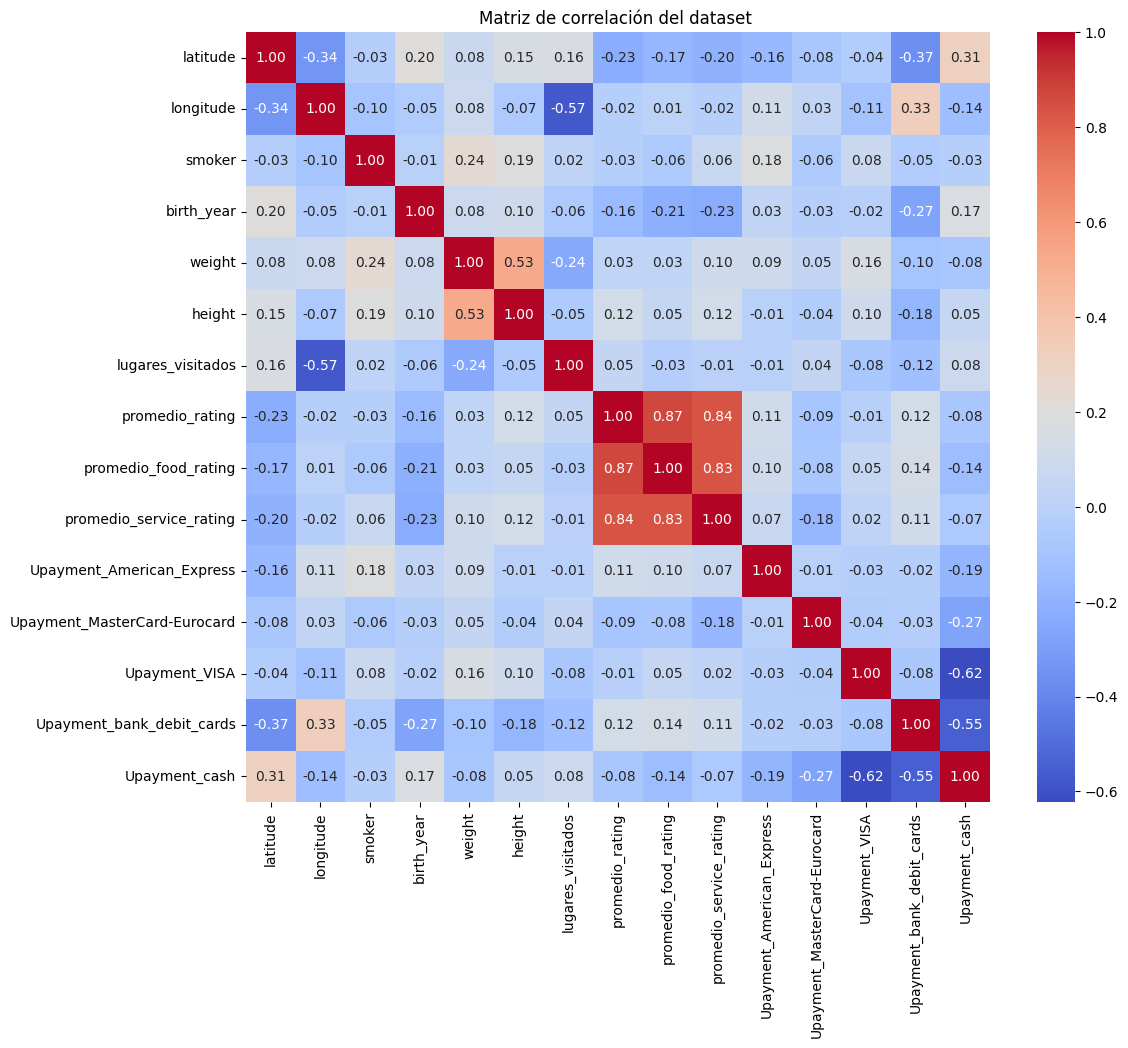

In [29]:
#  Seleccionar solo variables numéricas
import numpy as np

num_vars = dataset.select_dtypes(include=np.number)

#  Calcular la matriz de correlación
corr_matrix = num_vars.corr()

# Graficar la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de correlación del dataset ")
plt.show()

In [30]:
"""
En la matriz de correlacion visualmente observamos que nos hay correlacion=1 para poder eliminar esas variables 
"""




'\nEn la matriz de correlacion visualmente observamos que nos hay correlacion=1 para poder eliminar esas variables \n'

### Clustering para remover Multicolinealidad

In [31]:
columnas=P3.utils.multicolinealidad_clustering(dataset)

In [38]:
print(f'Las columnas a eliminar son:{columnas}')

Las columnas a eliminar son:['lugares_visitados', 'height', 'promedio_food_rating', 'promedio_service_rating', 'Upayment_cash']


## SeleckBest

In [39]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 0 to 137
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   userID                        128 non-null    object 
 1   latitude                      128 non-null    float64
 2   longitude                     128 non-null    float64
 3   smoker                        128 non-null    int64  
 4   drink_level                   128 non-null    object 
 5   ambience                      128 non-null    object 
 6   transport                     128 non-null    object 
 7   birth_year                    128 non-null    int64  
 8   interest                      128 non-null    object 
 9   personality                   128 non-null    object 
 10  color                         128 non-null    object 
 11  weight                        128 non-null    int64  
 12  height                        128 non-null    float64
 13  lugares_vi

In [41]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler

X = dataset.drop(columns=['smoker'])
y = dataset['smoker']

# Seleccionamos variables numéricas
num_vars = X.select_dtypes(include='number').columns

X_num = X[num_vars]

# Escalado
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_num)

# SelectKBest con ANOVA
selector = SelectKBest(score_func=f_classif, k=7)
X_new = selector.fit_transform(X_scaled, y)

selected_features = num_vars[selector.get_support()]
print(f'Variables seleccionadas (ANOVA): {selected_features}')


Variables seleccionadas (ANOVA): Index(['longitude', 'weight', 'height', 'promedio_food_rating',
       'promedio_service_rating', 'Upayment_American_Express',
       'Upayment_VISA'],
      dtype='object')


### Calculamos el WOE y IV sobre las variables categoricas 

In [32]:
woe_df,iv_df=P3.utils.calcular_woe_iv(dataset,'smoker')

/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [37]:
iv_df.columns

Index(['variable', 'IV'], dtype='object')

In [34]:
iv_df

,variable,IV
0,userID,inf
9,religion,inf
10,activity,inf
6,hijos,inf
5,marital_status,inf
12,budget,inf
1,drink_level,1.087688
4,transport,0.398792
11,color,0.357418
3,ambience,0.201435


In [35]:
dataset.drop(columns=['budget','marital_status','hijos','activity','religion','dress_preference'],inplace=True)

### Eliminamos el df de acuerdo a su valor IV <0.12

/tmp/ipykernel_5608/1757072038.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.drop(columns=['budget','marital_status','hijos','activity','religion','dress_preference'],inplace=True)


## Poder Predictivo SelectK best


In [36]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler

# Variable objetivo
X = dataset.drop(columns=['smoker'])
y = dataset['smoker']

# Seleccionamos columnas numéricas
num_vars = X.select_dtypes(include=['number']).columns
X_num = X[num_vars]

# Escalamos variables
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_num)

# Selección de k mejores variables con f_classif (ANOVA)
selector = SelectKBest(score_func=f_classif, k=7)
X_new = selector.fit_transform(X_scaled, y)

# Variables seleccionadas
selected_features = num_vars[selector.get_support()]

print(f'Las variables seleccionadas son: {selected_features}')


Las variables seleccionadas son: Index(['longitude', 'weight', 'height', 'promedio_food_rating',
       'promedio_service_rating', 'Upayment_American_Express',
       'Upayment_VISA'],
      dtype='object')
